In [95]:
# =============================================
# Récupération des IDs des objets du Lion Noir
# =============================================

#
# Import des bibliothèques
#

# pathlib : sert à manipuler des chemins de fichiers/dossiers proprement
from pathlib import Path

# requests : sert à envoyer des requêtes HTTP vers des sites web ou des API (interface de traitement d'applications entre un serveur web et un navigateur web
import requests

# pandas : sert à manipuler des tableaux de données
import pandas as pd

#
# Création des dossiers
#

# création d'une variable contenant le chemin du dossier principal (le "r" permet de ne pas considérer les possibles caractères spéciaux)
BASE_DIR = Path(r"C:\Users\lilia\Desktop\github\jupyter\GW2_project")

# création d'un chemin vers le dossier data
DATA_DIR = BASE_DIR / "data"

# création du dossier parents s'ils n'existent pas, de même pas de création si le dossier existe déjà
DATA_DIR.mkdir(parents=True, exist_ok=True)

#
# Connexion à l'API de Guild Wars 2 
#

# stock l'adresse de l'API des prix du marché
PRICES_URL = "https://api.guildwars2.com/v2/commerce/prices"

# stock l'adresse de l'API des objets existants
ITEMS_URL = "https://api.guildwars2.com/v2/items"

# envoi d'une requête pour récupérer les IDs des objets et .json() permet de transformer la réponse JSON en une liste python
market_ids = requests.get(PRICES_URL).json()

#
# Fonction pour découper les listes
#

# création d'une fonction qui va prendre en arguments une liste découper en n morceau et retourner des morceaux de cette liste
def chunks(lst, n=200): 
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

# création d'une liste vide qui a pour objectif de contenir les objets récupérés
items = []

#
# Boucle de récupération
#

# Parcourt les groupes de 200 IDs afin de récupérer les informations des objets issus du marché pour les ajouter à la liste "items"
for batch in chunks(market_ids):
    r = requests.get(
        ITEMS_URL,
        params={"ids": ",".join(map(str, batch))}
    )
    items.extend(r.json())

# transforme la liste "items" en tableau pandas
df_items = pd.DataFrame(items)

# sauvegarde du tableau
df_items.to_parquet(DATA_DIR / "items_market.parquet")

In [1]:
# ===========================
# Capture des prix du marché
# ===========================

#
# Import des bibliothèques
#

# pathlib : sert à manipuler des chemins de fichiers/dossiers proprement
from pathlib import Path

# datetime : sert à récupérer la date actuelle et l'heure actuelle
from datetime import datetime

# pandas : sert à manipuler des tableaux de données
import pandas as pd

# requests : sert à envoyer des requêtes HTTP vers des sites web ou des API (interface de traitement d'applications entre un serveur web et un navigateur web
import requests

#
# Création des dossiers
#

# création d'une variable contenant le chemin du dossier principal (le "r" permet de ne pas considérer les possibles caractères spéciaux)
BASE_DIR = Path(r"C:\Users\lilia\Desktop\github\jupyter\GW2_project")

# création d'un chemin vers le dossier data
DATA_DIR = BASE_DIR / "data"

# création d'un chemin vers le dossier historique
HISTORY_DIR = BASE_DIR / "history_v2" / "history"

# création du dossier parents s'ils n'existent pas, de même pas de création si le dossier existe déjà
HISTORY_DIR.mkdir(parents=True, exist_ok=True)

#
# Chargement des objets
#

# lit le fichier créé dans le premier script
items = pd.read_parquet(DATA_DIR / "items_market.parquet")

# récupération uniquement des "id", supprime les doublons et transforme la liste en objet python
active_ids = items["id"].unique().tolist()

#
# Fonction API permettant de récupérer le prix des objets
#

# création d'une fonction qui en parcourant la liste des "ids" va les découper en lot de 200 stocké dans "chunks"
# "all_prices" va stocker de manière temporaire tous les prix récupérer via la boucle batch
# les prix de chaque objets vont être récupérer via des boucles de 200 ids
# transformation des prix en tableau pandas
def get_prices(active_ids):
    chunks = [active_ids[i:i+200] for i in range(0, len(active_ids), 200)]
    all_prices = []
    for batch in chunks:
        r = requests.get(
            "https://api.guildwars2.com/v2/commerce/prices",
            params={"ids": ",".join(map(str, batch))}
        )
        if r.status_code != 200:
            continue
        data = r.json()
        if isinstance(data, list):
            all_prices.extend(data)
    return pd.DataFrame(all_prices)

# Appel de la fonction get_prices pour les ids
df_prices = get_prices(active_ids)

#
# Obtention de la table final
#

# Fusion de la table items obtenu avec le code dans la section précédente et la table prix obtenus ici
df_analysis = df_prices.merge(items,on="id",how="left")

# Ajout des informations temporelles : date et date + heure
df_analysis["snapshot_date"] = datetime.today().date()
df_analysis["snapshot_datetime"] = datetime.now()

# Nom du fichier
filename = f"prices_snapshot_{datetime.now().strftime('%Y-%m-%d_%H')}.parquet"

# Sauvegarde du fichier
df_analysis.to_parquet(HISTORY_DIR / filename)

# Message final
print("Snapshot saved:", filename)

Snapshot saved: prices_snapshot_2026-06-21_22.parquet


In [1]:
#------------------------------------------------------
# Fusion des snapshot dans un seul dataframe historique
#------------------------------------------------------

#
# Import des bibliothèques
#

# pathlib : sert à manipuler des chemins de fichiers/dossiers proprement
from pathlib import Path

# pandas : sert à manipuler des tableaux de données
import pandas as pd

#
# Création du fichier
#

# création d'une variable contenant le chemin du dossier principal (le "r" permet de ne pas considérer les possibles caractères spéciaux)
HISTORY_DIR = Path(r"C:\Users\lilia\Desktop\github\jupyter\GW2_project\history_v2\history")

# obtention de la liste contenant tout les fichiers finissant par .parquet
files = list(HISTORY_DIR.glob("*.parquet"))

# concaténation de tout les fichiers présent dans "files"
df_history = pd.concat([pd.read_parquet(file) for file in files],ignore_index=True)

# Trie par date et par id
df_history = df_history.sort_values(by=["snapshot_date", "id"])

# Vérification des dates
df_history["snapshot_date"].value_counts().sort_index()

snapshot_date
2026-06-10    167640
2026-06-11    670560
2026-06-12    670560
2026-06-13    670560
2026-06-14    642620
2026-06-15    667220
2026-06-16    670560
2026-06-17    363220
2026-06-18    502920
2026-06-19    670560
2026-06-20    670560
2026-06-21    558800
Name: count, dtype: int64

In [2]:
# ======================
# FORMAT MONNAIE
# ======================

# création d'une fonction permettant de formatter le nombre de pièces de cuivre au format de GW2
def format_money(copper): 
    copper = int(round(copper)) 
    
    gold = copper // 10000 
    silver = (copper % 10000) // 100 
    bronze = copper % 100 
    
    parts = [] 
    if gold > 0: 
        parts.append(f"{gold}PO") 
    if silver > 0: 
        parts.append(f"{silver}PA") 
    if bronze > 0: 
        parts.append(f"{bronze}PC") 
    
    return " ".join(parts) if parts else "0 PC"

In [3]:
# ================================
# MISE EN PLACE D'UNE TABLE PROPRE
# ================================

#
# Import des bibliothèques
#

# pandas : sert à manipuler des tableaux de données
import pandas as pd

# création d'une copie du fichier historique
df = df_history.copy()

#
# extraction des colonnes d'achat et de vente
#

# Extraction de la colonne "quantity" et "unit_price" grâce à "lambda x"
df["quantity_buys"] = df["buys"].apply(lambda x: x.get("quantity") if isinstance(x, dict) else None)
df["unit_price_buys"] = df["buys"].apply(lambda x: x.get("unit_price") if isinstance(x, dict) else None)
df["quantity_sells"] = df["sells"].apply(lambda x: x.get("quantity") if isinstance(x, dict) else None)
df["unit_price_sells"] = df["sells"].apply(lambda x: x.get("unit_price") if isinstance(x, dict) else None)

# formatage de la date
df["datetime_fmt"] = pd.to_datetime(df["snapshot_datetime"]).dt.strftime("%d/%m %Hh")


# construction de la table finale
final_df = df[[
    "id",
    "name",
    "type",
    "level",
    "rarity",
    "quantity_buys",
    "unit_price_buys",
    "quantity_sells",
    "unit_price_sells",
    "datetime_fmt"
]].copy()

# ajout des prix formatés
final_df["unit_price_buys_fmt"] = final_df["unit_price_buys"].apply(format_money)
final_df["unit_price_sells_fmt"] = final_df["unit_price_sells"].apply(format_money)

In [4]:
# ============================================
# FILTRE TABLE (Minerais / Chutes / Rondins / Segments)
# ============================================

minerais = {19697,19703,19699,19698,19702,19700,19701}
chutes = {19718,19739,19741,19743,19748,19745}
rondins = {19723,19726,19727,19724,19722,19725}
segments = {19719,19728,19730,19731,19729,19732}
os = {24342,24343,24344,24345,24341,24358}
griffe = {24346,24347,24348,24349,24350,24351}
poussiere = {24272,24273,24274,24275,24276,24277}
croc = {24352,24353,24354,24355,24356,24357}
ecaille = {24284,24285,24286,24287,24288,24289}
totem = {24296,24297,24298,24363,24299,24300}
venin = {24278,24279,24280,24281,24282,24283}
sang = {24290,24291,24292,24293,24294,24295}
essence = {24331,24332,24333,24334,24335}
onyx = {24306,24307,24308,24309,24310}
fusion = {24311,24312,24313,24314,24315}
glace = {24316,24317,24318,24319,24320}
destructeur = {24321,24322,24323,24324,24325}
cristal = {24326,24327,24328,24329,24330}
corrompu = {24336,24337,24338,24339,24340}
charge = {24301,24302,24303,24304,24305}
mordrem = {66930,70842}
verdoyant = {68952,68942}
resonant = {71428,75857,71049,75015}
trophee = {19976,19721}




categories = {
    "minerais": minerais,
    "chutes": chutes,
    "rondins": rondins,
    "segments": segments,
    "os": os,
    "griffe": griffe,
    "poussiere": poussiere,
    "croc": croc,
    "ecaille": ecaille,
    "totem": totem,
    "venin": venin,
    "sang": sang,
    "essence": essence,
    "onyx": onyx,
    "fusion": fusion,
    "glace": glace,
    "destructeur": destructeur,
    "cristal": cristal,
    "corrompu": corrompu,
    "charge": charge,
    "mordrem": mordrem,
    "verdoyant": verdoyant,
    "trophee": trophee
}

final_df["categorie"] = "autre"

for nom, ids in categories.items():
    final_df.loc[
        final_df["id"].isin(ids),
        "categorie"
    ] = nom


materiaux_df = final_df[final_df["categorie"] != "autre"].copy()

In [5]:
materiaux_df_v2 = materiaux_df[[
    "id",
    "name",
    "quantity_buys",
    "unit_price_buys_fmt",
    "quantity_sells",
    "unit_price_sells_fmt",
    "datetime_fmt"
]].copy()


materiaux_df_v2 = materiaux_df_v2.rename(
    columns={
        "quantity_buys": "qte_achat",
        "unit_price_buys_fmt": "prix_achat",
        "quantity_sells": "qte_vente",
        "unit_price_sells_fmt": "prix_vente",
        "datetime_fmt": "date"
    }
)

materiaux_df_v2

,id,name,qte_achat,prix_achat,qte_vente,prix_vente,date
9646,19697,Copper Ore,2681466,23PC,4516568,24PC,10/06 18h
37586,19697,Copper Ore,2680079,23PC,4514520,28PC,10/06 19h
65526,19697,Copper Ore,2681990,23PC,4513597,29PC,10/06 20h
93466,19697,Copper Ore,2678854,23PC,4514847,30PC,10/06 21h
121406,19697,Copper Ore,2687336,23PC,4517916,30PC,10/06 22h
...,...,...,...,...,...,...,...
6809020,70842,Mordrem Lodestone,21323,1PA 51PC,486633,2PA 39PC,21/06 15h
6836960,70842,Mordrem Lodestone,21229,1PA 50PC,486711,2PA 27PC,21/06 16h
6864900,70842,Mordrem Lodestone,22015,1PA 27PC,486417,2PA 25PC,21/06 17h
6892840,70842,Mordrem Lodestone,22031,1PA 29PC,486492,2PA 19PC,21/06 18h


In [6]:
import pandas as pd
import numpy as np

# ======================
# PARAMÈTRES
# ======================
CAPITAL = 20 * 10000   # cuivre
NB_POSITIONS = 10
MAX_QUANTITY_PER_ITEM = 100
TAX_RATE = 0.15

# ======================
# DERNIER SNAPSHOT
# ======================
latest_time = materiaux_df["datetime_fmt"].max()

latest_df = materiaux_df[
    materiaux_df["datetime_fmt"] == latest_time
].copy()

# ======================
# PROFIT UNITAIRE (taxe incluse)
# ======================
latest_df["profit_unitaire"] = (
    latest_df["unit_price_sells"] * (1 - TAX_RATE)
    - latest_df["unit_price_buys"]
)

latest_df["ROI"] = (
    latest_df["profit_unitaire"]
    / latest_df["unit_price_buys"]
)

# ======================
# ALLOCATION CAPITAL FIXE
# ======================
latest_df = latest_df.sort_values("ROI", ascending=False).copy()

capital_restant = CAPITAL

selected_rows = []

for _, row in latest_df.iterrows():

    price = row["unit_price_buys"]

    if price <= 0:
        continue

    max_qty = capital_restant // price

    qty = min(max_qty, MAX_QUANTITY_PER_ITEM)

    if qty <= 0:
        continue

    invest = qty * price

    new_row = row.copy()
    new_row["quantite_achetee"] = qty
    new_row["investissement"] = invest

    selected_rows.append(new_row)

    capital_restant -= invest

    if capital_restant <= 0:
        break

latest_df = pd.DataFrame(selected_rows)

# ======================
# PROFIT TOTAL
# ======================
latest_df["profit_total"] = (
    latest_df["quantite_achetee"] * latest_df["profit_unitaire"]
)

# ======================
# FILTRAGE OPPORTUNITÉS
# ======================
portfolio = (
    latest_df[
        (latest_df["ROI"] > 0.05) &
        (latest_df["profit_total"] > 0) &
        (latest_df["quantite_achetee"] > 0)
    ]
    .sort_values("profit_total", ascending=False)
    .head(NB_POSITIONS)
).copy()

# ======================
# RÉSUMÉ GLOBAL
# ======================
total_investissement = portfolio["investissement"].sum()
total_profit = portfolio["profit_total"].sum()

roi_portefeuille = (
    total_profit / total_investissement
    if total_investissement > 0 else 0
)

print("=== RÉSUMÉ PORTEFEUILLE ===")

print(
    "Investissement total :",
    format_money(total_investissement)
)

print(
    "Profit potentiel total :",
    format_money(total_profit)
)

print("ROI portefeuille :",format(roi_portefeuille, ".4f"))

# ======================
# FORMATAGE AFFICHAGE
# ======================
portfolio_v2 = portfolio[[
    "name",
    "unit_price_buys_fmt",
    "unit_price_sells_fmt",
    "profit_unitaire",
    "ROI",
    "quantite_achetee",
    "investissement",
    "profit_total",
    "datetime_fmt"
]].copy()

portfolio_v2["investissement"] = portfolio_v2["investissement"].apply(format_money)
portfolio_v2["profit_total"] = portfolio_v2["profit_total"].apply(format_money)

portfolio_v2

=== RÉSUMÉ PORTEFEUILLE ===
Investissement total : 16PO 72PA
Profit potentiel total : 9PO 50PA 25PC
ROI portefeuille : 0.5683


,name,unit_price_buys_fmt,unit_price_sells_fmt,profit_unitaire,ROI,quantite_achetee,investissement,profit_total,datetime_fmt
6908497,Molten Shard,4PA 52PC,6PA 99PC,142.15,0.314491,100,4PO 52PA,1PO 42PA 15PC,21/06 19h
6908495,Molten Sliver,1PA 16PC,3PA 3PC,141.55,1.220259,100,1PO 16PA,1PO 41PA 55PC,21/06 19h
6908492,Onyx Shard,3PA 53PC,5PA 78PC,138.30,0.391785,100,3PO 53PA,1PO 38PA 30PC,21/06 19h
6908491,Onyx Fragment,60PC,2PA 26PC,132.10,2.201667,100,60PA,1PO 32PA 10PC,21/06 19h
6908506,Destroyer Fragment,3PA 59PC,5PA 74PC,128.90,0.359053,100,3PO 59PA,1PO 28PA 90PC,21/06 19h
6920780,Mordrem Lodestone,1PA 27PC,2PA 46PC,82.10,0.646457,100,1PO 27PA,82PA 10PC,21/06 19h
6908487,Charged Shard,96PC,1PA 93PC,68.05,0.708854,100,96PA,68PA 5PC,21/06 19h
6908490,Onyx Sliver,19PC,80PC,49.00,2.578947,100,19PA,49PA,21/06 19h
6908500,Glacial Sliver,61PC,1PA 26PC,46.10,0.755738,100,61PA,46PA 10PC,21/06 19h
6908485,Charged Sliver,29PC,60PC,22.00,0.758621,100,29PA,22PA,21/06 19h


In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd


# Copie
df = materiaux_df.copy()

# Conversion datetime
df["datetime_fmt"] = pd.to_datetime(
    df["datetime_fmt"] + " 2026",
    format="%d/%m %Hh %Y"
)

# Prix net après taxe
df["net_unit_price_sells"] = (
    df["unit_price_sells"] * 0.85
)

# Spread

df["spread"] = (
    df["net_unit_price_sells"]
    - df["unit_price_buys"]
)

# ======================
# GRAPH PAR ITEM
# ======================

from matplotlib.backends.backend_pdf import PdfPages
import tempfile
import os

# PDF temporaire
pdf_path = tempfile.NamedTemporaryFile(
    suffix=".pdf",
    delete=False
).name


with PdfPages(pdf_path) as pdf:

    for item_id in df["id"].unique():

        item_df = (
            df[df["id"] == item_id]
            .sort_values("datetime_fmt")
        )
    
        name = item_df["name"].iloc[0]
    
        plt.figure(figsize=(14,6))
    
    
        plt.plot(
            item_df["datetime_fmt"],
            item_df["unit_price_buys"],
            linestyle="solid",
            label="Buy"
        )

        plt.plot(
            item_df["datetime_fmt"],
            item_df["unit_price_sells"],
            linestyle="dashed",
            label="Sell"
        )
    
        plt.plot(
            item_df["datetime_fmt"],
            item_df["net_unit_price_sells"],
            linestyle="dotted",
            label="Net Sell (taxe 15%)"
        )
    
    
        # ======================
        # FORMAT DATES
        # ======================
    
        ax = plt.gca()
    
        # une ligne verticale toutes les 4 heures
        ax.xaxis.set_major_locator(
            mdates.HourLocator(interval=4)
        )
        
        ax.xaxis.set_major_formatter(
            mdates.DateFormatter("%d/%m %Hh")
        )
        
        ax.grid(
            axis="x",
            linestyle="--",
            alpha=0.5
        )
    
        ax.set_xlim(
            left=pd.to_datetime("2026-06-10 16:00:00"),
            right=df["datetime_fmt"].max() + pd.Timedelta(hours=2)
        )
    
    
        plt.title(
            f"{name} ({item_id}) - Évolution prix GW2"
        )
    
        plt.xlabel("Temps")
        plt.ylabel("Prix (cuivre)")
    
        plt.legend()
        plt.xticks(rotation=45)
    
        plt.tight_layout()
        # ajoute la page au PDF
        pdf.savefig()

        plt.close()

# ouverture automatique du PDF
os.startfile(pdf_path)

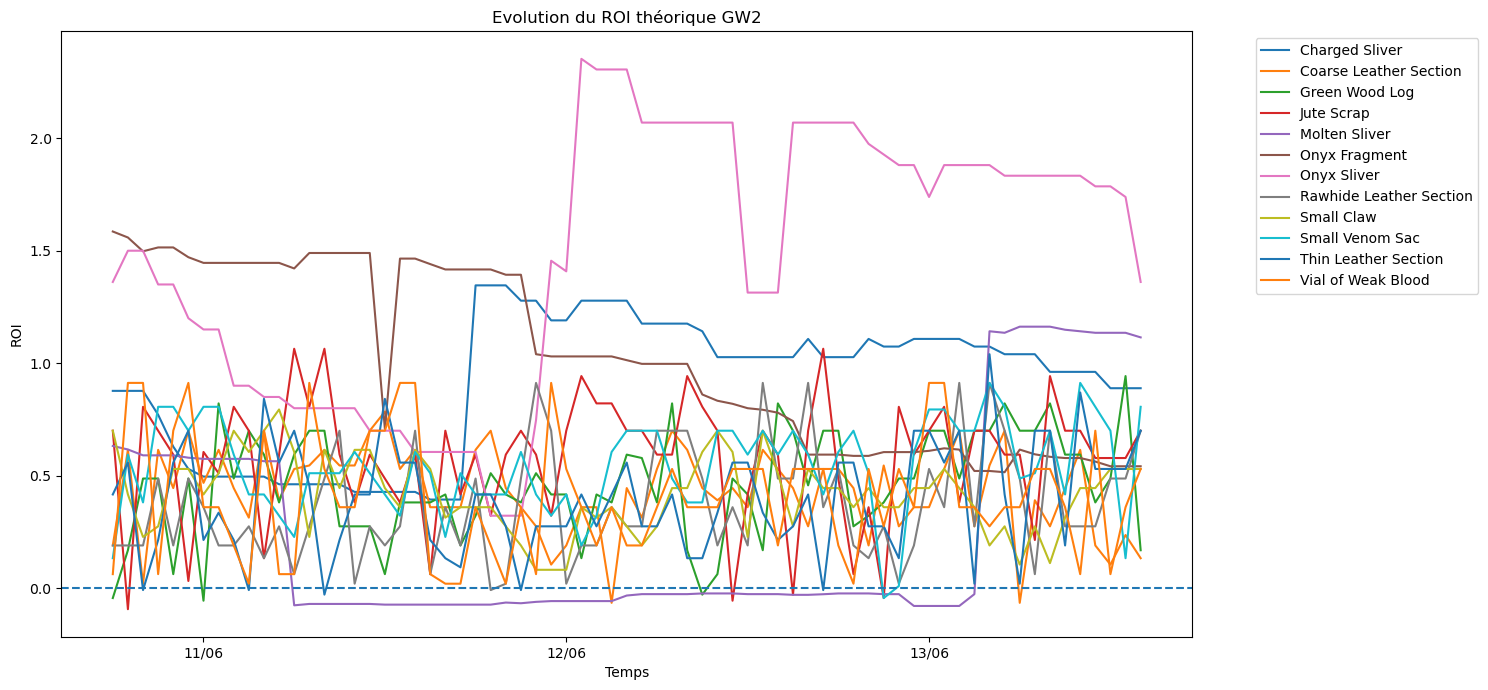

In [17]:
df = materiaux_df.copy()

# conversion date
df["datetime_fmt"] = pd.to_datetime(
    df["datetime_fmt"] + " 2026",
    format="%d/%m %Hh %Y"
)

# prix net après taxe
df["net_unit_price_sells"] = (
    df["unit_price_sells"] * 0.85
)

# profit théorique
df["profit_unitaire"] = (
    df["net_unit_price_sells"]
    - df["unit_price_buys"]
)

# ROI
df["ROI"] = (
    df["profit_unitaire"]
    /
    df["unit_price_buys"]
)


positive_items = (
    df.groupby("name")["ROI"]
    .max()
)

good_items = positive_items[
    positive_items > 0.75
].index


df_filtered = df[
    df["name"].isin(good_items)
].copy()


roi_series = df_filtered.pivot_table(
    index="datetime_fmt",
    columns="name",
    values="ROI"
)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


plt.figure(figsize=(15,7))


for item in roi_series.columns:

    plt.plot(
        roi_series.index,
        roi_series[item],
        label=item
    )


ax = plt.gca()

ax.xaxis.set_major_locator(
    mdates.DayLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%d/%m")
)


plt.axhline(
    0,
    linestyle="--"
)


plt.title(
    "Evolution du ROI théorique GW2"
)

plt.xlabel("Temps")
plt.ylabel("ROI")


plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()